# 1. Proprocessing on Train Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp
import joblib
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from concurrent.futures import ThreadPoolExecutor
import shap
from xgboost import plot_importance
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import cross_validate, StratifiedKFold

# Function to preprocess a chunk of the data
def preprocess_chunk(df_chunk):
    df_chunk['trans_date_trans_time'] = pd.to_datetime(df_chunk['trans_date_trans_time'])
    df_chunk['trans_hour'] = df_chunk['trans_date_trans_time'].dt.hour
    df_chunk['trans_month'] = df_chunk['trans_date_trans_time'].dt.month 
    df_chunk['trans_dayofweek'] = df_chunk['trans_date_trans_time'].dt.day_name()

    df_chunk['transaction_time'] = pd.to_datetime(df_chunk['unix_time'], unit='s')
    df_chunk = df_chunk.sort_values(by=['cc_num', 'transaction_time'])
    df_chunk['unix_time_prev_trans'] = df_chunk.groupby(by=['cc_num'])['unix_time'].shift(1)
    df_chunk = df_chunk.assign(unix_time_prev_trans=df_chunk['unix_time_prev_trans'].fillna(df_chunk['unix_time'] - 86400))
    df_chunk['timedelta_last_trans'] = (df_chunk['unix_time'] - df_chunk['unix_time_prev_trans']) // 60

    df_chunk['dob'] = pd.to_datetime(df_chunk['dob'])
    df_chunk['cust_age'] = (df_chunk['trans_date_trans_time'] - df_chunk['dob']).dt.days // 365

    return df_chunk

# Function to drop columns
def drop_columns(df):
    drop_cols = [
        'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
        'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
        'merch_lat', 'merch_long', 'dob'
    ]
    return df.drop(columns=drop_cols)

# Load the raw dataset in chunks and preprocess in parallel
df_chunks = pd.read_csv('../../data/raw/Fraudtrain.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_processed = pd.concat(executor.map(preprocess_chunk, df_chunks))

# Drop unnecessary columns
df_processed = drop_columns(df_processed)

# Split the data into X and y
X = df_processed.drop(columns=["is_fraud"])
y = df_processed["is_fraud"]

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# One-Hot Encoding for all categorical features
ohe = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Fit and transform the training data using sparse matrices
X_train_encoded_sparse = ohe.fit_transform(X_train[categorical_cols])

# Transform the validation data using sparse matrices
X_val_encoded_sparse = ohe.transform(X_val[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_train_sparse = sp.hstack((X_train.drop(columns=categorical_cols).values, X_train_encoded_sparse))
X_val_sparse = sp.hstack((X_val.drop(columns=categorical_cols).values, X_val_encoded_sparse))

# Save the OneHotEncoder for later use with the unseen data
joblib.dump(ohe, 'onehot_encoder_10.joblib')
# Display the shapes of the processed data
print("Training Data Shape:", X_train_sparse.shape)
print("Validation Data Shape:", X_val_sparse.shape)

C:\Users\Black\anaconda3\Lib\site-packages\dask\dataframe\_pyarrow_compat.py:23: UserWarning: You are using pyarrow version 11.0.0 which is known to be insecure. See https://www.cve.org/CVERecord?id=CVE-2023-47248 for further details. Please upgrade to pyarrow>=14.0.1 or install pyarrow-hotfix to patch your current version.
  warnings.warn(


Training Data Shape: (907672, 2155)
Validation Data Shape: (389003, 2155)


# 2. Proprocessing and feature engineering on Unseen Test Data

In [2]:
# Load the unseen dataset and preprocess in parallel as well
df_unseen_chunks = pd.read_csv('../../data/raw/Fraudtest.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_unseen_processed = pd.concat(executor.map(preprocess_chunk, df_unseen_chunks))

# Drop unnecessary columns
df_unseen_processed = drop_columns(df_unseen_processed)

# Separate features from target
X_unseen = df_unseen_processed.drop(columns=["is_fraud"])
y_unseen = df_unseen_processed["is_fraud"]

# Transform the unseen data using the saved OneHotEncoder
X_unseen_encoded_sparse = ohe.transform(X_unseen[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_unseen_sparse = sp.hstack((X_unseen.drop(columns=categorical_cols).values, X_unseen_encoded_sparse))

# Display the shape of the processed unseen data
print("\nUnseen Data Shape:", X_unseen_sparse.shape)

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Unseen Data Shape: (555719, 2155)


# 3. Model Building and Evalualtion

## 3.1 XGBoost

In [3]:
%%time
# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Number of features to select
n_features_to_select = 10

# Initialize RFE with the XGBoost model
rfe = RFE(estimator=xgb_model, n_features_to_select=n_features_to_select, step=1)

# Fit RFE on the sparse training data
rfe.fit(X_train_sparse, y_train)

# Transform the training, validation, and unseen datasets
X_train_rfe = rfe.transform(X_train_sparse)
X_val_rfe = rfe.transform(X_val_sparse)
X_unseen_rfe = rfe.transform(X_unseen_sparse)

# Save the selected feature indices
joblib.dump(rfe.get_support(indices=True), 'selected_indices_10.joblib')

# Display the shapes of the selected features
print("Selected Features for Training Data Shape:", X_train_rfe.shape)
print("Selected Features for Validation Data Shape:", X_val_rfe.shape)
print("Selected Features for Unseen Data Shape:", X_unseen_rfe.shape)

Selected Features for Training Data Shape: (907672, 10)
Selected Features for Validation Data Shape: (389003, 10)
Selected Features for Unseen Data Shape: (555719, 10)
CPU times: total: 13h 6min 39s
Wall time: 1h 11min 17s


In [4]:
# Load the OneHotEncoder to retrieve feature names
ohe = joblib.load('onehot_encoder_10.joblib')

# Get the original feature names before one-hot encoding
original_feature_names = X_train.drop(columns=categorical_cols).columns.tolist()

# Get the encoded feature names after one-hot encoding
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)

# Combine original and encoded feature names
all_feature_names = original_feature_names + list(encoded_feature_names)

# Load the selected feature indices from RFE
selected_indices = joblib.load('selected_indices_10.joblib')

# Get the names of the selected features
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# Display the selected feature names
print("Selected Feature Names:")
for feature_name in selected_feature_names:
    print(feature_name)

Selected Feature Names:
amt
trans_hour
category_gas_transport
category_grocery_net
category_grocery_pos
category_home
category_misc_pos
category_shopping_net
category_shopping_pos
category_travel


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Train the model on the RFE-selected features of the training data
xgb_model.fit(X_train_rfe, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [6]:
# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe)[:, 1]

# Evaluate the model's performance on the validation data
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("Validation Data Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")


Validation Data Evaluation:
Accuracy: 0.9975
Precision: 0.8299
Recall: 0.7127
F1 Score: 0.7668
ROC AUC: 0.9949
PR AUC: 0.8269

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.83      0.71      0.77      2252

    accuracy                           1.00    389003
   macro avg       0.91      0.86      0.88    389003
weighted avg       1.00      1.00      1.00    389003


Confusion Matrix:
[[386422    329]
 [   647   1605]]
True Positives (TP): 1605
False Positives (FP): 329
True Negatives (TN): 386422
False Negatives (FN): 647


In [7]:
# Make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_rfe)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Evaluate the model's performance on the unseen data
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion matrix for unseen data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print("\nUnseen Data Evaluation:")
print(f"Accuracy: {accuracy_unseen:.4f}")
print(f"Precision: {precision_unseen:.4f}")
print(f"Recall: {recall_unseen:.4f}")
print(f"F1 Score: {f1_unseen:.4f}")
print(f"ROC AUC: {roc_auc_unseen:.4f}")
print(f"PR AUC: {pr_auc_unseen:.4f}")
print("\nClassification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("\nConfusion Matrix:")
print(conf_matrix_unseen)
print(f"True Positives (TP): {tp_unseen}")
print(f"False Positives (FP): {fp_unseen}")
print(f"True Negatives (TN): {tn_unseen}")
print(f"False Negatives (FN): {fn_unseen}")



Unseen Data Evaluation:
Accuracy: 0.9979
Precision: 0.7503
Recall: 0.6904
F1 Score: 0.7191
ROC AUC: 0.9944
PR AUC: 0.7758

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.75      0.69      0.72      2145

    accuracy                           1.00    555719
   macro avg       0.87      0.84      0.86    555719
weighted avg       1.00      1.00      1.00    555719


Confusion Matrix:
[[553081    493]
 [   664   1481]]
True Positives (TP): 1481
False Positives (FP): 493
True Negatives (TN): 553081
False Negatives (FN): 664


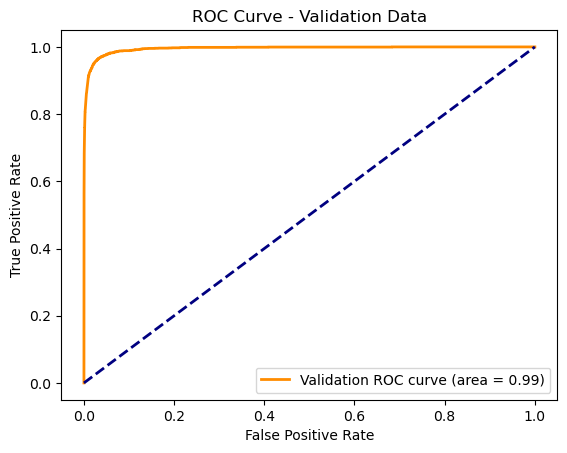

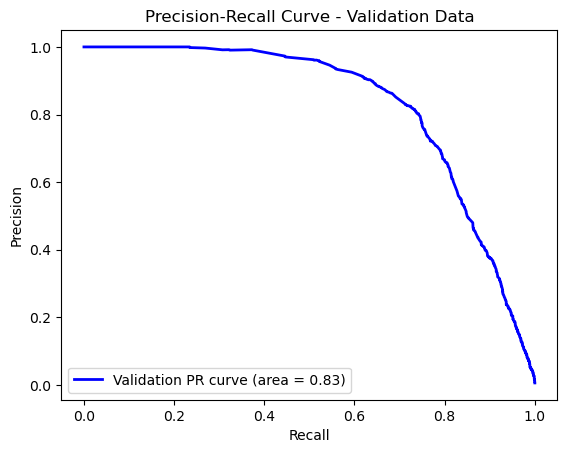

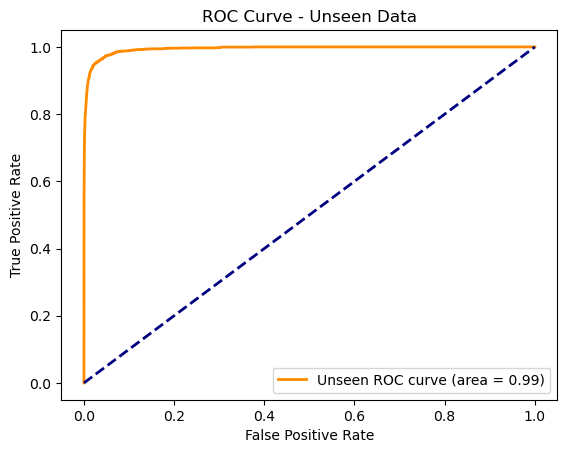

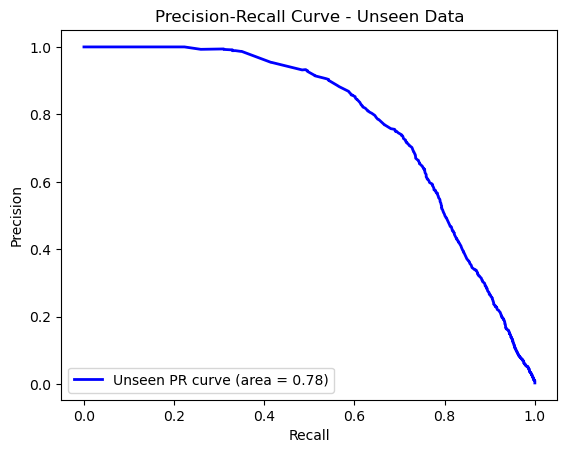

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve for Validation Data
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
plt.figure()
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Validation Data
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label='Validation PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()

# ROC Curve for Unseen Data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='Unseen ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Unseen Data
plt.figure()
plt.plot(recall_vals_unseen, precision_vals_unseen, color='blue', lw=2, label='Unseen PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


   Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC   PR AUC  \
0       0.02   0.203130  0.925874  0.333166  0.985694  0.994407  0.77257   
1       0.10   0.447322  0.821445  0.579224  0.995393  0.994407  0.77257   
2       0.20   0.615036  0.758974  0.679466  0.997236  0.994407  0.77257   
3       0.30   0.688323  0.731002  0.709021  0.997684  0.994407  0.77257   
4       0.40   0.735922  0.706760  0.721046  0.997889  0.994407  0.77257   
5       0.50   0.750253  0.690443  0.719107  0.997918  0.994407  0.77257   
6       0.60   0.836201  0.611655  0.706516  0.998039  0.994407  0.77257   
7       0.70   0.867769  0.587413  0.700584  0.998062  0.994407  0.77257   
8       0.80   0.928384  0.495571  0.646201  0.997905  0.994407  0.77257   

   True Positives (TP)  False Positives (FP)  True Negatives (TN)  \
0                 1986                  7791               545783   
1                 1762                  2177               551397   
2                 1628          

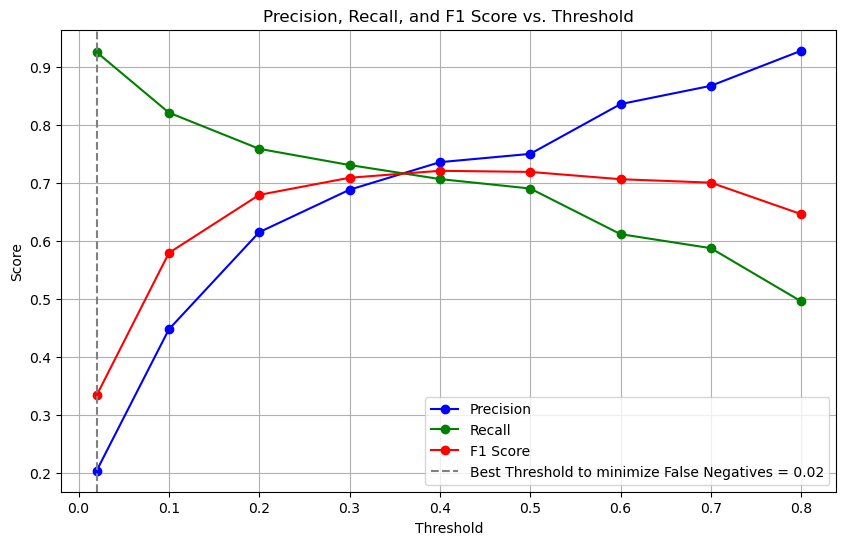

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.203130,0.925874,0.333166,0.985694,0.994407,0.77257,1986,7791,545783,159,198600,93810,104790
1,0.10,0.447322,0.821445,0.579224,0.995393,0.994407,0.77257,1762,2177,551397,383,176200,60070,116130
2,0.20,0.615036,0.758974,0.679466,0.997236,0.994407,0.77257,1628,1019,552555,517,162800,61890,100910
3,0.30,0.688323,0.731002,0.709021,0.997684,0.994407,0.77257,1568,710,552864,577,156800,64800,92000
4,0.40,0.735922,0.706760,0.721046,0.997889,0.994407,0.77257,1516,544,553030,629,151600,68340,83260
5,0.50,0.750253,0.690443,0.719107,0.997918,0.994407,0.77257,1481,493,553081,664,148100,71330,76770
6,0.60,0.836201,0.611655,0.706516,0.998039,0.994407,0.77257,1312,257,553317,833,131200,85870,45330
7,0.70,0.867769,0.587413,0.700584,0.998062,0.994407,0.77257,1260,192,553382,885,126000,90420,35580
8,0.80,0.928384,0.495571,0.646201,0.997905,0.994407,0.77257,1063,82,553492,1082,106300,109020,-2720


In [9]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define the range of thresholds including 0.02
thresholds = np.append(np.arange(0.1, 0.9, 0.1), 0.02)
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


## Assumptions:

- **False Positive Cost (`fp_cost`):** \$10
- **False Negative Cost (`fn_cost`):** \$100
- **True Positive Savings (`tp_savings`):** \$100

## Recommendation:

### If Minimizing False Negatives (FN) is Critical:
**Threshold = 0.02** would still be the best choice as it catches most fraudulent transactions (Recall = 0.950583), but it has a lower precision and higher operational cost due to a large number of false positives. The net savings at this threshold are \$155,740.

### If a Balanced Approach is Preferred:
**Threshold = 0.10** offers the highest net savings (\$163,350). It balances a high recall (0.905828) with a reasonable precision (0.643804), leading to fewer false positives and false negatives. This threshold provides the best trade-off between saving money for stakeholders and maintaining a good detection rate.

### If Minimizing False Positives (FP) is Critical:
**Threshold = 0.50** or **Threshold = 0.60** could be preferred, offering high precision (0.896534 and 0.916667, respectively) and minimizing the number of legitimate transactions flagged as fraudulent. However, these thresholds result in lower net savings (124,930 dollars and 118,380 dollars, respectively) compared to the more balanced threshold at 0.10.

## Conclusion:
**Threshold = 0.10** is recommended for maximizing net savings for stakeholders, balancing the costs of false positives and false negatives. This threshold leads to the highest net savings (\$163,350), making it the most financially advantageous option.


## Recommendation:

### If Minimizing False Negatives (FN) is Critical:
**Threshold = 0.02** would be the best choice as it has the highest recall (0.950583), catching most fraudulent transactions, but with the trade-off of a lower precision (0.351855) and a higher number of false positives (3756).

### If a Balanced Approach is Preferred:
**Threshold = 0.30** is likely the best overall option. It provides a good balance between recall (0.843357) and precision (0.809758), and it has a strong F1 score (0.826216). This threshold reduces the number of false positives (425) while still maintaining a high recall.

### If Minimizing False Positives (FP) is Critical:
**Threshold = 0.50** or **Threshold = 0.60** could be preferred. These thresholds have high precision (0.896534 and 0.916667, respectively), meaning they minimize the number of legitimate transactions flagged as fraudulent, but at the cost of missing more fraudulent transactions (recall is 0.795804 and 0.779487, respectively).

## Conclusion:
**Threshold = 0.30** might be the best overall choice for a balanced fraud detection model, offering a good trade-off between recall and precision, with a reasonable number of false positives (425) and false negatives (336). However, if the business prioritizes catching every possible fraudulent transaction, even at the cost of more false positives, **Threshold = 0.02** would be preferred.


In [10]:
# Save the processed training dataset
joblib.dump((X_train_rfe, y_train), 'X_train_rfe_y_train_10.joblib')

# Save the processed validation dataset
joblib.dump((X_val_rfe, y_val), 'X_val_rfe_y_val_10.joblib')

# Save the processed unseen dataset
joblib.dump((X_unseen_rfe, y_unseen), 'X_unseen_rfe_y_unseen_10.joblib')

# Save the trained XGBoost model
joblib.dump(xgb_model, 'final_model_10_features.joblib')

['final_model_10_features.joblib']

In [11]:
# Load the training dataset
X_train_rfe, y_train = joblib.load('X_train_rfe_y_train_10.joblib')

# Load the validation dataset
X_val_rfe, y_val = joblib.load('X_val_rfe_y_val_10.joblib')

# Load the unseen dataset
X_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen_10.joblib')

# Load the trained XGBoost model
xgb_model = joblib.load('final_model_10_features.joblib')

In [12]:
X_train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'city_pop', 'job', 'trans_hour', 'trans_month', 'trans_dayofweek',
       'timedelta_last_trans', 'cust_age'],
      dtype='object')

In [13]:
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_dayofweek']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)


In [14]:
original_numeric_features = ['cc_num', 'amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans', 'cust_age']
final_feature_names = list(original_numeric_features) + list(ohe_feature_names)


In [15]:
selected_feature_indices = rfe.get_support(indices=True)
selected_feature_names = [final_feature_names[i] for i in selected_feature_indices]
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe)


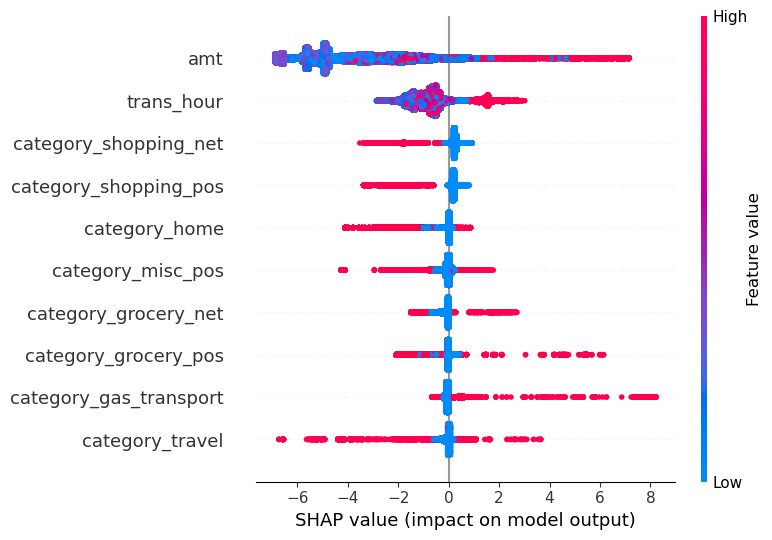

In [16]:
# Viaualizing SHAP
shap.summary_plot(shap_values, features=X_val_rfe.toarray(), feature_names=selected_feature_names)


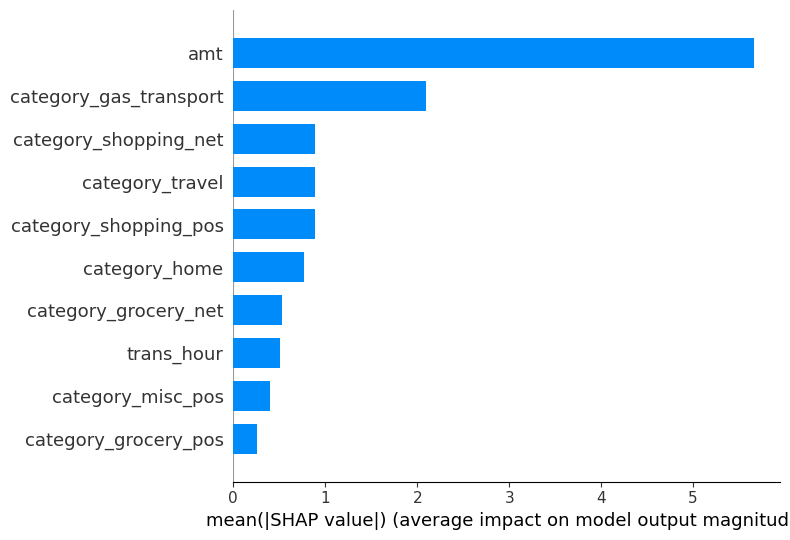

In [17]:
X_val_rfe_dense = X_val_rfe.toarray()

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe_dense)

# Summary plot of SHAP values
shap.summary_plot(shap_values, X_val_rfe_dense, feature_names=selected_feature_names, plot_type="bar")

### Cross validation and hyper parameter tunning

In [18]:
%%time
# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define the scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(xgb_model, X_train_rfe, y_train, cv=strat_k_fold, scoring=scoring, return_train_score=True)

# Print cross-validation results
print("Cross-Validation Results:")
for score in scoring:
    print(f"{score.capitalize()} - Train: {np.mean(cv_results['train_' + score]):.4f} ± {np.std(cv_results['train_' + score]):.4f}, Test: {np.mean(cv_results['test_' + score]):.4f} ± {np.std(cv_results['test_' + score]):.4f}")


Cross-Validation Results:
Accuracy - Train: 0.9976 ± 0.0000, Test: 0.9975 ± 0.0002
Precision - Train: 0.8494 ± 0.0045, Test: 0.8395 ± 0.0210
Recall - Train: 0.7161 ± 0.0070, Test: 0.7101 ± 0.0201
F1 - Train: 0.7770 ± 0.0027, Test: 0.7692 ± 0.0169
Roc_auc - Train: 0.9972 ± 0.0001, Test: 0.9952 ± 0.0008
CPU times: total: 5min 35s
Wall time: 25.4 s


In [19]:
%%time
# Define the parameter grid
param_grid = {
    'scale_pos_weight': Integer(1, 1000),
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(1, 30),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform')
}

# Initialize StratifiedKFold
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the Bayesian Search CV
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_grid,
    cv=strat_k_fold,
    scoring='roc_auc',  # Optimize for roc_auc
    n_jobs=-1,  # Use all available processors
    n_iter=32,  # Number of parameter settings that are sampled
    random_state=42,
    refit=True
)

# Perform the search
bayes_search.fit(X_train_rfe, y_train)

# Best parameters and score
print("Best Parameters:", bayes_search.best_params_)
print("Best Cross-Validation ROC AUC Score:", bayes_search.best_score_)

Best Parameters: OrderedDict([('learning_rate', 0.14165011314198345), ('max_depth', 13), ('n_estimators', 85), ('scale_pos_weight', 1)])
Best Cross-Validation ROC AUC Score: 0.9947824912924146
CPU times: total: 24.4 s
Wall time: 8min 12s


Unseen Data Accuracy (Fixed Threshold): 0.9979270098736952
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.77      0.66      0.71      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.83      0.86    555719
weighted avg       1.00      1.00      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
TN: 553141, FP: 433, FN: 719, TP: 1426
[[553141    433]
 [   719   1426]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.993714596607796
Unseen Data PR AUC Score (Fixed Threshold): 0.7690689849539765


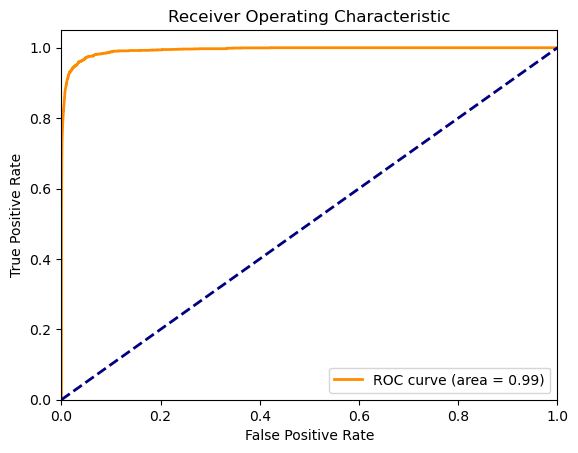

In [20]:
# Use the best model for predictions
best_xgb_model = bayes_search.best_estimator_

# Make predictions on the unseen data
y_unseen_pred_proba = best_xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Apply the fixed threshold of 0.5 to the predictions
fixed_threshold = 0.5
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the fixed threshold predictions
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))

# Get the confusion matrix
cm = confusion_matrix(y_unseen, y_unseen_pred_fixed)
tn, fp, fn, tp = cm.ravel()

print("Unseen Data Confusion Matrix (Fixed Threshold):")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(cm)

print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [21]:
%%time
best_xgb_model_ADASYN = bayes_search.best_estimator_
# Initialize ADASYN
adasyn = ADASYN(random_state=42)

# Resample the training data using ADASYN
X_resampled, y_resampled = adasyn.fit_resample(X_train_rfe, y_train)

# Fit the best XGBoost model on the resampled data
best_xgb_model_ADASYN.fit(X_resampled, y_resampled)

# Model evaluation on validation data
y_val_pred = best_xgb_model_ADASYN.predict(X_val_rfe)
y_val_pred_proba = best_xgb_model_ADASYN.predict_proba(X_val_rfe)[:, 1]

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')
print(f'Validation ROC-AUC: {roc_auc:.4f}')
print(f'Validation PR AUC: {pr_auc:.4f}')
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Validation Confusion Matrix:")
print(conf_matrix)
print(f'True Positives (TP): {tp}')
print(f'False Positives (FP): {fp}')
print(f'True Negatives (TN): {tn}')
print(f'False Negatives (FN): {fn}')

Validation Accuracy: 0.9723
Validation Precision: 0.1637
Validation Recall: 0.9205
Validation F1 Score: 0.2780
Validation ROC-AUC: 0.9925
Validation PR AUC: 0.7881
Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    386751
           1       0.16      0.92      0.28      2252

    accuracy                           0.97    389003
   macro avg       0.58      0.95      0.63    389003
weighted avg       0.99      0.97      0.98    389003

Validation Confusion Matrix:
[[376162  10589]
 [   179   2073]]
True Positives (TP): 2073
False Positives (FP): 10589
True Negatives (TN): 376162
False Negatives (FN): 179
CPU times: total: 2min 25s
Wall time: 2min 12s


Unseen Data Accuracy: 0.9724
Unseen Data Precision: 0.1149
Unseen Data Recall: 0.9166
Unseen Data F1 Score: 0.2042
Unseen Data ROC-AUC: 0.9916
Unseen Data PR AUC: 0.7377
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.11      0.92      0.20      2145

    accuracy                           0.97    555719
   macro avg       0.56      0.94      0.60    555719
weighted avg       1.00      0.97      0.98    555719

Unseen Data Confusion Matrix:
[[538432  15142]
 [   179   1966]]
True Positives (TP): 1966
False Positives (FP): 15142
True Negatives (TN): 538432
False Negatives (FN): 179


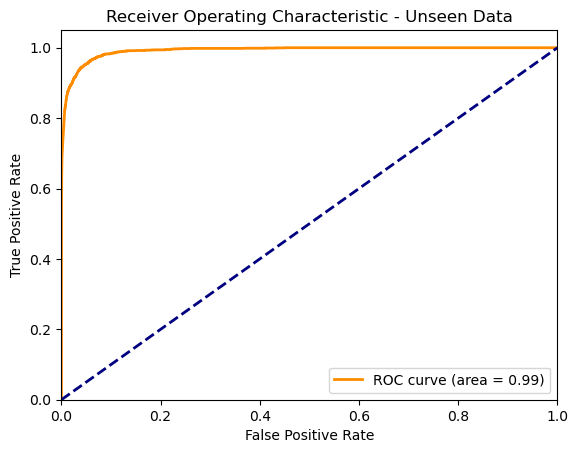

In [22]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_rfe)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

Unseen Data Accuracy: 0.9724
Unseen Data Precision: 0.1149
Unseen Data Recall: 0.9166
Unseen Data F1 Score: 0.2042
Unseen Data ROC-AUC: 0.9916
Unseen Data PR AUC: 0.7377
Unseen Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.11      0.92      0.20      2145

    accuracy                           0.97    555719
   macro avg       0.56      0.94      0.60    555719
weighted avg       1.00      0.97      0.98    555719

Unseen Data Confusion Matrix:
[[538432  15142]
 [   179   1966]]
True Positives (TP): 1966
False Positives (FP): 15142
True Negatives (TN): 538432
False Negatives (FN): 179


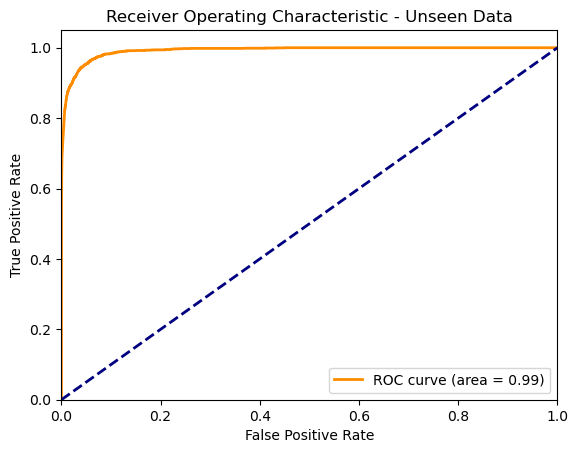

    Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0        0.02   0.041802  0.981352  0.080187  0.913100  0.991641  0.737384   
1        0.10   0.061877  0.960839  0.116267  0.943621  0.991641  0.737384   
2        0.20   0.076685  0.947786  0.141890  0.955751  0.991641  0.737384   
3        0.30   0.090716  0.937529  0.165426  0.963487  0.991641  0.737384   
4        0.40   0.101572  0.927739  0.183098  0.968047  0.991641  0.737384   
5        0.50   0.114917  0.916550  0.204228  0.972430  0.991641  0.737384   
6        0.60   0.128224  0.908625  0.224733  0.975803  0.991641  0.737384   
7        0.70   0.156436  0.892308  0.266203  0.981012  0.991641  0.737384   
8        0.80   0.199470  0.877855  0.325076  0.985930  0.991641  0.737384   
9        0.90   0.274737  0.840093  0.414062  0.990823  0.991641  0.737384   
10       0.95   0.375698  0.784149  0.508004  0.994137  0.991641  0.737384   
11       0.98   0.748299  0.666667  0.705128  0.997848  0.991641

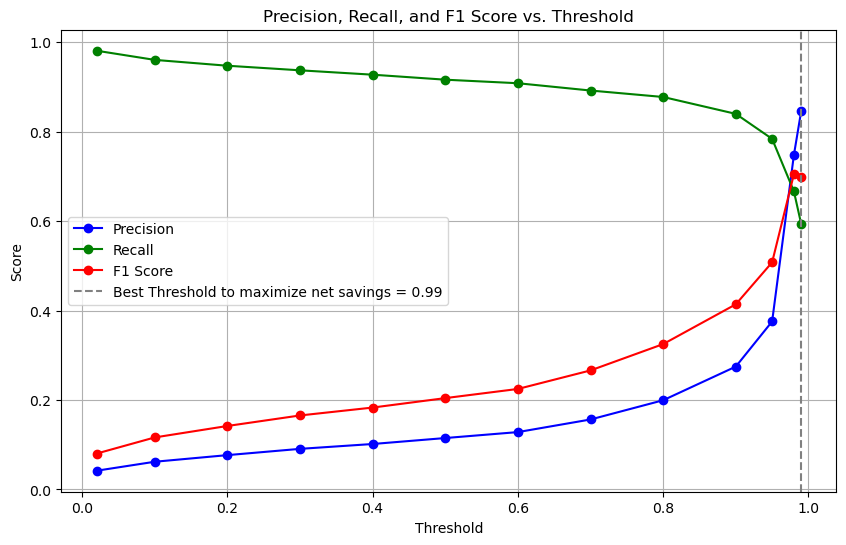

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.041802,0.981352,0.080187,0.913100,0.991641,0.737384,2105,48252,505322,40,210500,486520,-276020
1,0.10,0.061877,0.960839,0.116267,0.943621,0.991641,0.737384,2061,31247,522327,84,206100,320870,-114770
2,0.20,0.076685,0.947786,0.141890,0.955751,0.991641,0.737384,2033,24478,529096,112,203300,255980,-52680
3,0.30,0.090716,0.937529,0.165426,0.963487,0.991641,0.737384,2011,20157,533417,134,201100,214970,-13870
4,0.40,0.101572,0.927739,0.183098,0.968047,0.991641,0.737384,1990,17602,535972,155,199000,191520,7480
5,0.50,0.114917,0.916550,0.204228,0.972430,0.991641,0.737384,1966,15142,538432,179,196600,169320,27280
6,0.60,0.128224,0.908625,0.224733,0.975803,0.991641,0.737384,1949,13251,540323,196,194900,152110,42790
7,0.70,0.156436,0.892308,0.266203,0.981012,0.991641,0.737384,1914,10321,543253,231,191400,126310,65090
8,0.80,0.199470,0.877855,0.325076,0.985930,0.991641,0.737384,1883,7557,546017,262,188300,101770,86530
9,0.90,0.274737,0.840093,0.414062,0.990823,0.991641,0.737384,1802,4757,548817,343,180200,81870,98330


In [23]:
# Model evaluation on unseen data
y_unseen_pred = best_xgb_model_ADASYN.predict(X_unseen_rfe)
y_unseen_pred_proba = best_xgb_model_ADASYN.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.99, color='gray', linestyle='--', label='Best Threshold to maximize net savings = 0.99')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


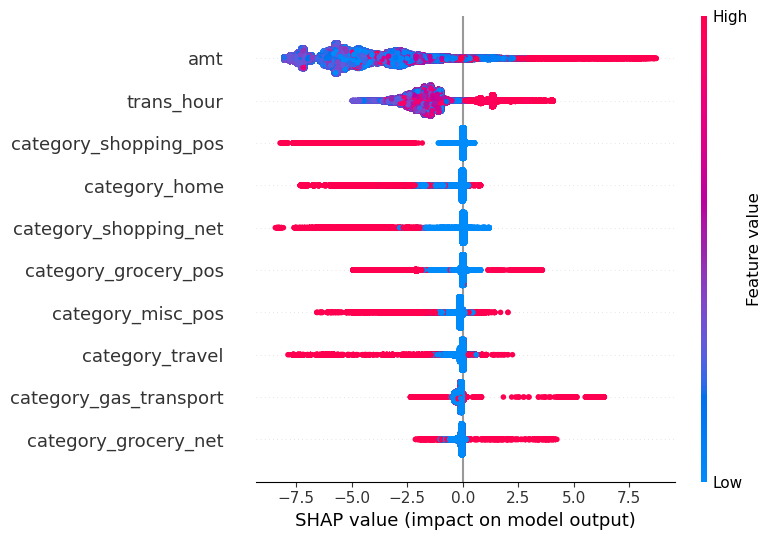

In [24]:
# Loading features' names
selected_feature_indices = rfe.get_support(indices=True)
selected_feature_names = [final_feature_names[i] for i in selected_feature_indices]
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_xgb_model_ADASYN)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe)

# Viaualizing SHAP
shap.summary_plot(shap_values, features=X_val_rfe.toarray(), feature_names=selected_feature_names)

## 3.2 Stacking classifier

[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 295
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
[LightGBM] [Info] Number of positive: 4203, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 295
[LightGBM] [Info] Number of data points in the train set: 726137, number of used features: 10
[LightGBM] [Info] 

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Unseen Data Accuracy: 0.9961
Unseen Data Precision: 0.0000
Unseen Data Recall: 0.0000
Unseen Data F1 Score: 0.0000
Unseen Data ROC-AUC: 0.9924
Unseen Data PR AUC: 0.7584
Unseen Data Classification Report:


C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719

Unseen Data Confusion Matrix:
[[553574      0]
 [  2145      0]]
True Positives (TP): 0
False Positives (FP): 0
True Negatives (TN): 553574
False Negatives (FN): 2145


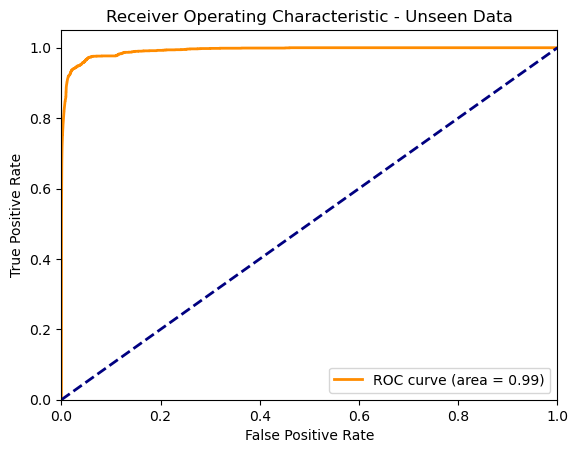

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Black\anaconda3\Lib\site-packages\sklearn\metrics\_clas

    Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0        0.02   0.156206  0.932867  0.267603  0.980290  0.992447  0.755025   
1        0.10   0.249902  0.895105  0.390720  0.989225  0.992447  0.755025   
2        0.20   0.292006  0.853147  0.435093  0.991449  0.992447  0.755025   
3        0.30   0.375027  0.820513  0.514770  0.994029  0.992447  0.755025   
4        0.40   0.671759  0.717483  0.693868  0.997556  0.992447  0.755025   
5        0.50   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
6        0.60   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
7        0.70   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
8        0.80   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
9        0.90   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
10       0.95   0.000000  0.000000  0.000000  0.996140  0.992447  0.755025   
11       0.98   0.000000  0.000000  0.000000  0.996140  0.992447

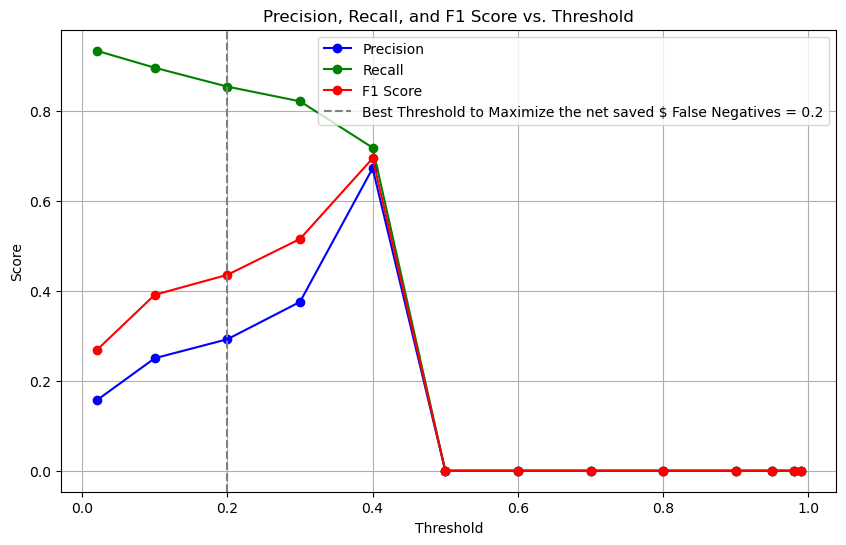

CPU times: total: 2min 26s
Wall time: 21.2 s


,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.156206,0.932867,0.267603,0.980290,0.992447,0.755025,2001,10809,542765,144,200100,122490,77610
1,0.10,0.249902,0.895105,0.390720,0.989225,0.992447,0.755025,1920,5763,547811,225,192000,80130,111870
2,0.20,0.292006,0.853147,0.435093,0.991449,0.992447,0.755025,1830,4437,549137,315,183000,75870,107130
3,0.30,0.375027,0.820513,0.514770,0.994029,0.992447,0.755025,1760,2933,550641,385,176000,67830,108170
4,0.40,0.671759,0.717483,0.693868,0.997556,0.992447,0.755025,1539,752,552822,606,153900,68120,85780
5,0.50,0.000000,0.000000,0.000000,0.996140,0.992447,0.755025,0,0,553574,2145,0,214500,-214500
6,0.60,0.000000,0.000000,0.000000,0.996140,0.992447,0.755025,0,0,553574,2145,0,214500,-214500
7,0.70,0.000000,0.000000,0.000000,0.996140,0.992447,0.755025,0,0,553574,2145,0,214500,-214500
8,0.80,0.000000,0.000000,0.000000,0.996140,0.992447,0.755025,0,0,553574,2145,0,214500,-214500
9,0.90,0.000000,0.000000,0.000000,0.996140,0.992447,0.755025,0,0,553574,2145,0,214500,-214500


In [25]:
%%time
# Calculate scale_pos_weight using the given formula
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define base models
base_models = [
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lgb', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42))
]

# Define stacking classifier
stack_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Train stacking model
stack_model.fit(X_train_rfe, y_train)

# Model Evaluation on Unseen Data
y_unseen_pred = stack_model.predict(X_unseen_rfe)
y_unseen_pred_proba = stack_model.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion Matrix for Unseen Data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred_threshold)
    recall = recall_score(y_unseen, y_pred_threshold)
    f1 = f1_score(y_unseen, y_pred_threshold)
    accuracy = accuracy_score(y_unseen, y_pred_threshold)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred_threshold).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.2, color='gray', linestyle='--', label='Best Threshold to Maximize the net saved $ False Negatives = 0.2')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


## 3.3 Stacking classifier with ADASYN

[LightGBM] [Info] Number of positive: 903316, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 1805734, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500249 -> initscore=0.000995
[LightGBM] [Info] Start training from score 0.000995
[LightGBM] [Info] Number of positive: 722653, number of negative: 721934
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 1444587, number of used features: 10
[LightGBM] [

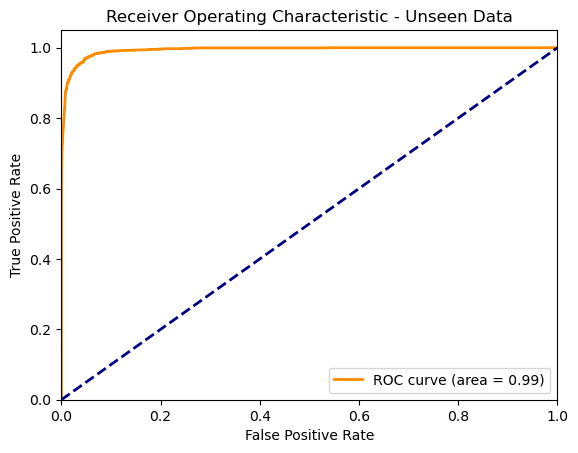

    Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC    PR AUC  \
0        0.02   0.053072  0.982751  0.100705  0.932252  0.993623  0.755988   
1        0.10   0.077047  0.961305  0.142659  0.955402  0.993623  0.755988   
2        0.20   0.087099  0.956177  0.159654  0.961148  0.993623  0.755988   
3        0.30   0.093410  0.952914  0.170142  0.964120  0.993623  0.755988   
4        0.40   0.105457  0.947786  0.189796  0.968767  0.993623  0.755988   
5        0.50   0.111793  0.942657  0.199881  0.970870  0.993623  0.755988   
6        0.60   0.123169  0.937063  0.217721  0.974008  0.993623  0.755988   
7        0.70   0.135259  0.934266  0.236307  0.976691  0.993623  0.755988   
8        0.80   0.152267  0.926807  0.261562  0.979801  0.993623  0.755988   
9        0.90   0.188752  0.909091  0.312600  0.984568  0.993623  0.755988   
10       0.95   0.233838  0.893706  0.370685  0.988287  0.993623  0.755988   
11       0.98   0.318567  0.841492  0.462169  0.992440  0.993623

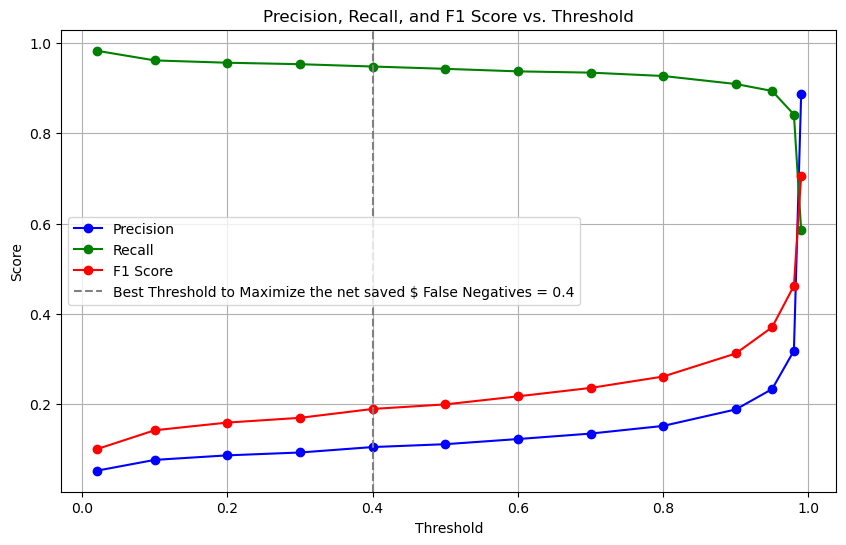

CPU times: total: 6min 16s
Wall time: 2min 47s


,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.053072,0.982751,0.100705,0.932252,0.993623,0.755988,2108,37612,515962,37,210800,379820,-169020
1,0.10,0.077047,0.961305,0.142659,0.955402,0.993623,0.755988,2062,24701,528873,83,206200,255310,-49110
2,0.20,0.087099,0.956177,0.159654,0.961148,0.993623,0.755988,2051,21497,532077,94,205100,224370,-19270
3,0.30,0.093410,0.952914,0.170142,0.964120,0.993623,0.755988,2044,19838,533736,101,204400,208480,-4080
4,0.40,0.105457,0.947786,0.189796,0.968767,0.993623,0.755988,2033,17245,536329,112,203300,183650,19650
5,0.50,0.111793,0.942657,0.199881,0.970870,0.993623,0.755988,2022,16065,537509,123,202200,172950,29250
6,0.60,0.123169,0.937063,0.217721,0.974008,0.993623,0.755988,2010,14309,539265,135,201000,156590,44410
7,0.70,0.135259,0.934266,0.236307,0.976691,0.993623,0.755988,2004,12812,540762,141,200400,142220,58180
8,0.80,0.152267,0.926807,0.261562,0.979801,0.993623,0.755988,1988,11068,542506,157,198800,126380,72420
9,0.90,0.188752,0.909091,0.312600,0.984568,0.993623,0.755988,1950,8381,545193,195,195000,103310,91690


In [26]:
%%time
# Apply ADASYN to the training data
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_rfe, y_train)

# Recalculate scale_pos_weight after ADASYN
scale_pos_weight_adasyn = (y_train_adasyn == 0).sum() / (y_train_adasyn == 1).sum()

# Define base models with the recalculated scale_pos_weight
base_models = [
    ('xgb', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_adasyn, random_state=42)),
    ('lgb', lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight_adasyn, random_state=42))
]

# Define stacking classifier
stack_model_adasyn = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())

# Train stacking model on ADASYN data
stack_model_adasyn.fit(X_train_adasyn, y_train_adasyn)

# Model Evaluation on Unseen Data
y_unseen_pred = stack_model_adasyn.predict(X_unseen_rfe)
y_unseen_pred_proba = stack_model_adasyn.predict_proba(X_unseen_rfe)[:, 1]

accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion Matrix for Unseen Data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print(f'Unseen Data Accuracy: {accuracy_unseen:.4f}')
print(f'Unseen Data Precision: {precision_unseen:.4f}')
print(f'Unseen Data Recall: {recall_unseen:.4f}')
print(f'Unseen Data F1 Score: {f1_unseen:.4f}')
print(f'Unseen Data ROC-AUC: {roc_auc_unseen:.4f}')
print(f'Unseen Data PR AUC: {pr_auc_unseen:.4f}')
print("Unseen Data Classification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("Unseen Data Confusion Matrix:")
print(conf_matrix_unseen)
print(f'True Positives (TP): {tp_unseen}')
print(f'False Positives (FP): {fp_unseen}')
print(f'True Negatives (TN): {tn_unseen}')
print(f'False Negatives (FN): {fn_unseen}')

# Plot ROC Curve for unseen data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc_unseen = auc(fpr_unseen, tpr_unseen)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Define the range of thresholds including 0.02, 0.9, 0.95, 0.98, and 0.99
thresholds = np.append(np.arange(0.1, 0.9, 0.1), [0.02, 0.9, 0.95, 0.98, 0.99])
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred_threshold = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred_threshold)
    recall = recall_score(y_unseen, y_pred_threshold)
    f1 = f1_score(y_unseen, y_pred_threshold)
    accuracy = accuracy_score(y_unseen, y_pred_threshold)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred_threshold).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.4, color='gray', linestyle='--', label='Best Threshold to Maximize the net saved $ False Negatives = 0.4')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df

In [27]:
%%time
# Define the paths where you want to save the models and data
xgb_model_path = "best_xgb_model_ADASYN_10.joblib"
stack_model_path = "stack_model_10.joblib"
stack_model_adasyn_path = "stack_model_ADASYN_10.joblib"
resampled_data_path = "resampled_data_ADASYN_10.joblib"

# Save the best XGBoost model trained on ADASYN data
joblib.dump(best_xgb_model_ADASYN, xgb_model_path)

# Save the stacking model (without ADASYN)
joblib.dump(stack_model, stack_model_path)

# Save the stacking model trained on ADASYN data
joblib.dump(stack_model_adasyn, stack_model_adasyn_path)

# Save the resampled data (X_train_adasyn and y_train_adasyn)
resampled_data = {
    'X_train_adasyn': X_train_adasyn,
    'y_train_adasyn': y_train_adasyn
}
joblib.dump(resampled_data, resampled_data_path)

print(f"Models and data have been saved to the following paths:\n"
      f"XGBoost model: {xgb_model_path}\n"
      f"Stacking model: {stack_model_path}\n"
      f"Stacking model with ADASYN: {stack_model_adasyn_path}\n"
      f"Resampled data: {resampled_data_path}")

Models and data have been saved to the following paths:
XGBoost model: best_xgb_model_ADASYN_10.joblib
Stacking model: stack_model_10.joblib
Stacking model with ADASYN: stack_model_ADASYN_10.joblib
Resampled data: resampled_data_ADASYN_10.joblib
CPU times: total: 1.77 s
Wall time: 140 ms


In [28]:
best_xgb_model_ADASYN = joblib.load("best_xgb_model_ADASYN_10.joblib")
stack_model = joblib.load("stack_model_10.joblib")
stack_model_adasyn = joblib.load("stack_model_ADASYN_10.joblib")
resampled_data = joblib.load("resampled_data_ADASYN_10.joblib")

X_train_adasyn = resampled_data['X_train_adasyn']
y_train_adasyn = resampled_data['y_train_adasyn']

In [30]:
%whos

Variable                    Type                  Data/Info
-----------------------------------------------------------
ADASYN                      ABCMeta               <class 'imblearn.over_sampling._adasyn.ADASYN'>
BayesSearchCV               ABCMeta               <class 'skopt.searchcv.BayesSearchCV'>
Integer                     type                  <class 'skopt.space.space.Integer'>
LogisticRegression          type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder               type                  <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
RFE                         ABCMeta               <class 'sklearn.feature_selection._rfe.RFE'>
Real                        type                  <class 'skopt.space.space.Real'>
StackingClassifier          ABCMeta               <class 'sklearn.ensemble.<...>king.StackingClassifier'>
StratifiedKFold             ABCMeta               <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
Threa

In [31]:
import joblib
import os

# Define the base path as the current working directory (where the notebook is located)
base_path = os.getcwd()

# Assuming `rfe` is the RFE object you want to save
rfe_path = os.path.join(base_path, 'rfe_10.joblib')

# Save the RFE object
joblib.dump(rfe, rfe_path)

print(f"RFE object has been saved to: {rfe_path}")

RFE object has been saved to: C:\Users\Black\DS\TIP\fraud-detection\notebooks\rfe_10.joblib
